In [2]:
import calendar
import string
from pathlib import Path
from typing import cast

import cmocean.cm as cmo
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from matplotlib import cm
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.figure import Figure
from scipy.stats import distributions
from tqdm import tqdm

In [3]:
FIG_SAVE_FMT = "png"

In [9]:
NOTEBOOK_DIR = Path().resolve()
DATA_DIR = NOTEBOOK_DIR / "../data"
FIGURES_DIR = NOTEBOOK_DIR / "../figures"
INNER_NITRATE_PATH = (
    DATA_DIR / "CE01ISSP/CE01ISSP_nitrate_binned_baseline_subtracted_2014-04-17_2023-09-17_with_dndt_resampled_v2.nc"
)
MIDSHELF_NITRATE_PATH = (
    DATA_DIR / "CE02SHSP/CE02SHSP_nitrate_binned_baseline_subtracted_2015-03-18_2024-07-14_with_dndt_resampled_v2.nc"
)
WIND_PATH = DATA_DIR / "NDBC_46050/46050_wind_binned_with_w5d_w8d.nc"
VEL_PATH = DATA_DIR / "NH10_Mooring_Data/nh10_hourly_data_1997_2024_rotated_filtered_streamwise_v5.2.nc"
OPTAA_PATH = DATA_DIR / "CE01ISSM/ce01issm_optaa_processed.nc"
FLORT_PATH = DATA_DIR / "CE01ISSM/ce01issm_flort_processed.nc"

VELOCITY_VARIABLE = "cs"

In [11]:
inner_nitrate = xr.open_dataset(INNER_NITRATE_PATH)
midshelf_nitrate = xr.open_dataset(MIDSHELF_NITRATE_PATH)
wind = xr.open_dataset(WIND_PATH, decode_timedelta=True)
velocity = xr.open_dataset(VEL_PATH)
optaa = xr.open_dataset(OPTAA_PATH)
flort = xr.open_dataset(FLORT_PATH)

# align optaa and flort datasets and average estimated chlorophyll
flort = flort.drop_dims("stats")
optaa_al, flort_al = xr.align(optaa.drop_duplicates("time"), flort.drop_duplicates("time"))

inner_shelf_chlorophyll = xr.Dataset(
    {
        "estimated_chlorophyll_flort": flort_al["estimated_chlorophyll"],
        "estimated_chlorophyll_optaa": optaa_al["estimated_chlorophyll"],
    },
)
inner_shelf_chlorophyll["estimated_chlorophyll"] = inner_shelf_chlorophyll.to_array(dim="new").mean(dim="new")
inner_shelf_chlorophyll = inner_shelf_chlorophyll.resample(time="1D").mean()

## Nitrate and Wind Time Series

Text(0.02, 0.95, 'Downwelling\nFavorable')

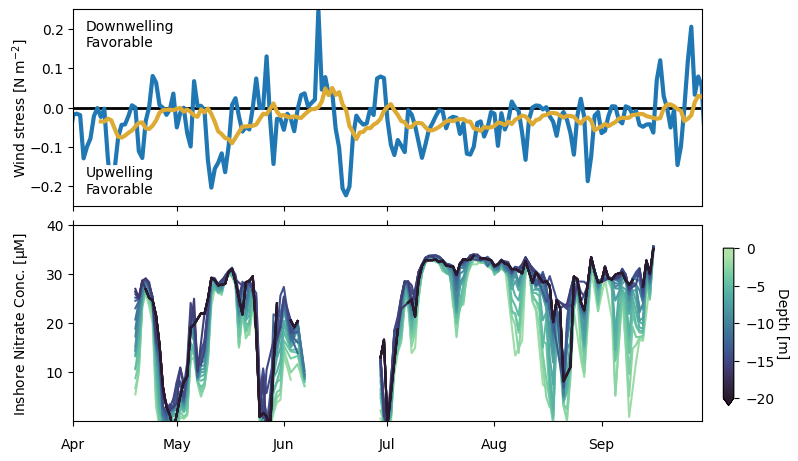

In [8]:
YEAR = 2021
INNER_SHELF_MAX_DEPTH = 21.5  # meters
MAX_NITRATE_CONC = 38  # uM

# single year time series
# plt.
fig, axs = plt.subplots(2, 1, figsize=(7, 4.5), sharex=True, layout="constrained")
temp = wind.where(wind["time.year"] == YEAR, drop=True)
(ln1,) = axs[0].plot(temp.time, temp.coare_y, label="Stress", lw=3, zorder=1.8)
(ln2,) = axs[0].plot(temp.time, temp.w5d, color="#DDAA33", label="$W_{5d}$", lw=3, zorder=1.8)
axs[0].axhline(0, ls="-", lw=2, color="black", zorder=1.5)
axs[0].set_ylim(-0.25, 0.25)

axs[0].set_xlim(np.datetime64("2021-04-01"), np.datetime64("2021-09-30"))
axs[0].tick_params(axis="x", which="minor", bottom=False, top=False)

deployment = np.arange(15, 20, 1)
temp = inner_nitrate.where(inner_nitrate["time.year"] == YEAR, drop=True)

cmap = cmo.tools.crop_by_percent(
    cmo.deep,  # pyright: ignore[reportAttributeAccessIssue]
    10,
    which="min",
    N=len(temp.depth.where(temp.depth < INNER_SHELF_MAX_DEPTH, drop=True)),
)
cdict = cmo.tools.get_dict(cmap, N=len(temp.depth.where(temp.depth < INNER_SHELF_MAX_DEPTH, drop=True)))
deep = LinearSegmentedColormap("cmap", cdict)

for i, d in enumerate(temp.depth):
    for dep in deployment:
        temp_dep = temp.where(temp.deployment == dep).where(temp.nitrate < MAX_NITRATE_CONC)
        if (len(temp_dep.time) > 0) & (~np.all(np.isnan(temp.sel(depth=d).nitrate))):
            axs[1].plot(
                temp_dep.sel(depth=d).time,
                temp_dep.sel(depth=d).nitrate,
                color=deep((i + 1) / len(inner_nitrate.depth)),
                lw=1.5,
            )

axs[1].tick_params(axis="x", which="major", bottom=True, top=True, pad=8)
dformatter = mdates.DateFormatter("%b")
axs[1].xaxis.set_major_formatter(dformatter)
axs[0].set_ylabel("Wind stress [$\\mathsf{N \\; m^{-2}}$]", labelpad=0)

axs[1].tick_params(axis="x", which="minor", bottom=False, top=False)
axs[1].set_ylim(0, 40)
axs[1].set_yticks([10, 20, 30, 40])
axs[1].set_ylabel("Inshore Nitrate Conc. [$\\mathsf{\\mu M}$]", labelpad=0)
fig.align_ylabels(axs)  # pyright: ignore[reportArgumentType]


deep_r = cmo.tools.crop_by_percent(
    cmo.deep_r,  # pyright: ignore[reportAttributeAccessIssue]
    10,
    which="max",
    N=len(temp.depth.where(temp.depth < INNER_SHELF_MAX_DEPTH, drop=True)),  # pyright: ignore[reportAttributeAccessIssue]
)
cax = fig.add_axes(
    rect=(
        axs[1].get_position().x0 + 0.9,
        axs[1].get_position().y0,
        0.015,
        axs[1].get_position().height,
    ),
)
scm = plt.cm.ScalarMappable(cmap=deep_r, norm=plt.Normalize(vmin=-20, vmax=0))  # pyright: ignore[reportAttributeAccessIssue]
cbar = fig.colorbar(scm, cax=cax, ax=axs, fraction=0.01, extend="min")
cbar.ax.tick_params(labelsize=10, pad=5)
cbar.ax.minorticks_off()
cbar.set_label("Depth [m]", labelpad=10, rotation=270)

axs[0].text(
    0.02,
    0.05,
    "Upwelling\nFavorable",
    bbox={"facecolor": "white", "alpha": 1, "edgecolor": "white", "boxstyle": "round,pad=0."},
    transform=axs[0].transAxes,
    va="bottom",
    ha="left",
    zorder=2,
)
axs[0].text(
    0.02,
    0.95,
    "Downwelling\nFavorable",
    bbox={"facecolor": "white", "alpha": 1, "edgecolor": "white", "boxstyle": "round,pad=0."},
    transform=axs[0].transAxes,
    va="top",
    ha="left",
    zorder=2,
)

In [ ]:
def _plot_wind_time_series(
    ax: plt.Axes,
    wind: xr.Dataset,
    year: int,
) -> None:
    wind = wind.where(wind["time.year"] == year, drop=True)

    ax.plot(wind.time, wind.coare_y, linestyle="-", linewidth=1, color="#4477AA", label="Stress", zorder=1.8)
    ax.plot(wind.time, wind.w5d, linestyle="-", linewidth=2, color="#EE6677", label=r"$\mathrm{W_{5d}}$", zorder=1.8)
    ax.axhline(0, ls="-", lw=2, color="black", zorder=1.5)
    ax.set_ylim(-0.25, 0.25)
    ax.set_xlim(np.datetime64(f"{year}-04-01"), np.datetime64(f"{year}-09-30"))
    ax.tick_params(axis="x", which="minor", bottom=False, top=False)
    ax.text(
        0.02,
        0.05,
        "Upwelling\nFavorable",
        bbox={"facecolor": "white", "alpha": 1, "edgecolor": "white", "boxstyle": "round,pad=0."},
        transform=ax.transAxes,
        va="bottom",
        ha="left",
        zorder=2,
    )
    ax.text(
        0.02,
        0.95,
        "Downwelling\nFavorable",
        bbox={"facecolor": "white", "alpha": 1, "edgecolor": "white", "boxstyle": "round,pad=0."},
        transform=ax.transAxes,
        va="top",
        ha="left",
        zorder=2,
    )
    ax.set_ylabel("Along-shelf wind stress\n[$\\mathsf{N\\;m^{-2}}$]")
    ax.legend(ncols=2, loc="upper right", frameon=True, framealpha=1, columnspacing=1)


def _plot_velocity_time_series(
    ax: plt.Axes,
    velocity: xr.Dataset,
    year: int,
) -> None:
    velocity = velocity.where(velocity["time.year"] == year, drop=True)

    ax.axhline(0, zorder=1.5, color="k")
    ax.plot(
        velocity.time,
        velocity.sel(depth=30)["u_proj"],
        linestyle="-",
        linewidth=1,
        label="30 m",
        color="#4477AA",
    )
    ax.plot(
        velocity.time,
        velocity.sel(depth=70)["u_proj"],
        linestyle="-",
        linewidth=2,
        label="70 m",
        color="#EE6677",
    )
    ax.set_ylabel("Cross-shelf\nVelocity [$\\mathsf{m \\; s^{-1}}$]")
    ax.legend(
        ncols=2,
        loc="upper right",
        frameon=True,
        framealpha=1,
        columnspacing=1,
    )
    ax.text(
        0.02,
        0.05,
        "Offshore",
        bbox={"facecolor": "white", "alpha": 1, "edgecolor": "white", "boxstyle": "round,pad=0."},
        transform=ax.transAxes,
        va="bottom",
        ha="left",
        zorder=2,
    )
    ax.text(
        0.02,
        0.95,
        "Onshore",
        bbox={"facecolor": "white", "alpha": 1, "edgecolor": "white", "boxstyle": "round,pad=0."},
        transform=ax.transAxes,
        va="top",
        ha="left",
        zorder=2,
    )


def _plot_nitrate_time_series(
    fig: Figure,
    ax: plt.Axes,
    nitrate: xr.Dataset,
    year: int,
    location: str,
) -> None:
    # Filter to year and max depth
    nitrate = nitrate.where(nitrate["time.year"] == year)
    # Use negative depths for plotting
    nitrate["depth"] = -nitrate["depth"]
    nitrate = nitrate.sortby("depth")

    # Get unique deployments
    deployments = np.unique(nitrate["deployment"])
    deployments = deployments[~np.isnan(deployments)]

    # Setup colormap and discrete colors
    deep_r = cmo.tools.crop_by_percent(
        cmo.deep_r,  # pyright: ignore[reportAttributeAccessIssue]; reversed so deeper is darker
        20,
        which="max",
        N=len(nitrate["depth"]),
    )
    colors = deep_r(np.linspace(0, 1, len(nitrate["depth"])))

    # Plot each depth and deployment
    black_line_depths = np.arange(-80, 1, 10)
    for i, depth in enumerate(nitrate["depth"].to_numpy()):
        ax.plot(
            nitrate.sel(depth=depth).time,
            nitrate.sel(depth=depth).nitrate,
            color=colors[i],
            lw=0.5,
        )
        if depth in black_line_depths:
            ax.plot(
                nitrate.sel(depth=depth).time,
                nitrate.sel(depth=depth).nitrate,
                color="black",
                lw=2,
            )

    # Format x-axis
    dformatter = mdates.DateFormatter("%b")
    ax.xaxis.set_major_formatter(dformatter)

    # Format y-axis
    ax.set_ylim(0, 40)
    ax.set_yticks([0, 10, 20, 30, 40])
    if location.lower() == "midshelf":
        ax.set_ylabel("Midshelf nitrate conc.\n[$\\mathsf{mmol \\; m^{-3}}$]")
    elif location.lower() == "inner":
        ax.set_ylabel("Inshore nitrate conc.\n[$\\mathsf{mmol \\; m^{-3}}$]")
    else:
        ax.set_ylabel("Nitrate conc.\n[$\\mathsf{mmol \\; m^{-3}}$]")

    # Add colorbar
    cax = ax.inset_axes([1.02, 0, 0.02, 1])
    scm = cm.ScalarMappable(cmap=deep_r, norm=mcolors.Normalize(vmin=nitrate["depth"].min(), vmax=0))
    cbar = fig.colorbar(scm, cax=cax, fraction=0.01)
    cbar.ax.tick_params(labelsize=10, pad=5)
    cbar.ax.minorticks_off()
    cbar.set_label("z [m]", labelpad=10, rotation=270)


def _plot_chlorophyll_time_series(
    ax: plt.Axes,
    chlorophyll: xr.Dataset,
    year: int,
) -> None:
    chlorophyll = chlorophyll.where(chlorophyll["time.year"] == year, drop=True)

    ax.plot(
        chlorophyll.time,
        chlorophyll.estimated_chlorophyll,
        linestyle="-",
        linewidth=2,
        color="#228833",
    )
    ax.set_ylabel("Estimated chlorophyll\n[$\\mathsf{mg \\; m^{-3}}$]")
    ax.set_ylim(0, 25)


def plot_wind_velocity_nitrate_time_series(
    wind: xr.Dataset,
    velocity: xr.Dataset,
    inner_nitrate: xr.Dataset,
    midshelf_nitrate: xr.Dataset,
    year: int,
    *,  # make save a keyword-only argument
    save: bool = False,
    max_nitrate_conc: float = np.inf,
    max_inner_shelf_depth: float = np.inf,
    max_midshelf_depth: float = np.inf,
) -> None:
    """Plot wind, velocity, and nitrate time series for a given year.

    Args:
        wind (xr.Dataset): xarray Dataset containing wind data.
        velocity (xr.Dataset): xarray Dataset containing ADCP velocity data.
        inner_nitrate (xr.Dataset): xarray Dataset containing inner shelf nitrate data.
        midshelf_nitrate (xr.Dataset): xarray Dataset containing midshelf nitrate data.
        year (int): Year to plot.
        save (bool, optional): Whether to save the figure. Defaults to False.
        max_nitrate_conc (float, optional): Maximum nitrate concentration to plot. Defaults to np.inf.
        max_inner_shelf_depth (float, optional): Maximum depth for inner shelf nitrate. Defaults to np.inf.
        max_midshelf_depth (float, optional): Maximum depth for midshelf nitrate. Defaults to np.inf.

    """
    # Don't show plot if saving
    if save:
        plt.ioff()
    fig, axs = plt.subplots(5, 1, figsize=(10, 10), sharex=True, layout="constrained")

    axs = cast("list[plt.Axes]", list(axs))
    fig.align_ylabels(axs)

    # Plot each time series
    _plot_wind_time_series(axs[0], wind, year)
    _plot_velocity_time_series(axs[1], velocity, year)
    _plot_nitrate_time_series(fig, axs[2], inner_nitrate, year, "inner", max_nitrate_conc, max_inner_shelf_depth)
    _plot_nitrate_time_series(fig, axs[3], midshelf_nitrate, year, "midshelf", max_nitrate_conc, max_midshelf_depth)
    _plot_chlorophyll_time_series(axs[4], inner_shelf_chlorophyll, year)

    # Add panel labels and turn off minor ticks
    for i, ax in enumerate(axs):
        ax.minorticks_off()
        ax.annotate(
            f"({string.ascii_lowercase[i]})",
            xy=(0.95, 0.05),
            xycoords="axes fraction",
            fontsize=10,
            bbox={"facecolor": "white", "alpha": 1, "edgecolor": "white", "boxstyle": "round,pad=0."},
        )

    if save:
        plt.savefig(
            FIGURES_DIR / f"manuscript/si/{FIG_SAVE_FMT}/wind-nitrate-time-series-{year}.{FIG_SAVE_FMT}",
            format=FIG_SAVE_FMT,
            bbox_inches="tight",
            dpi=600,
        )
    # Manually show plot if not saving
    if not save:
        plt.show()
    # Restore interactive mode for future plots
    plt.ion()
    plt.close()

In [53]:
for i in tqdm(range(2014, 2025)):
    plot_wind_velocity_nitrate_time_series(
        wind,
        velocity,
        inner_nitrate,
        midshelf_nitrate,
        i,
        save=True,
    )

100%|██████████| 11/11 [00:26<00:00,  2.41s/it]


In [80]:
midshelf_depth_mean_monthly = (
    midshelf_nitrate["nitrate"].mean(dim="depth").groupby("time.month").mean(dim="time").to_dataset()
)
midshelf_depth_mean_monthly["nitrate_std"] = (
    midshelf_nitrate["nitrate"].mean(dim="depth").groupby("time.month").std(dim="time")
)
midshelf_depth_mean_monthly["nitrate_count"] = (
    midshelf_nitrate["nitrate"].mean(dim="depth").groupby("time.month").count(dim="time")
)
midshelf_depth_mean_monthly["nitrate_ci"] = (
    midshelf_depth_mean_monthly["nitrate_std"] * distributions.t(10 - 1).isf(0.025) / np.sqrt(10)
)

inner_depth_mean_monthly = (
    inner_nitrate["nitrate"].mean(dim="depth").groupby("time.month").mean(dim="time").to_dataset()
)
inner_depth_mean_monthly["nitrate_std"] = (
    inner_nitrate["nitrate"].mean(dim="depth").groupby("time.month").std(dim="time")
)
inner_depth_mean_monthly["nitrate_count"] = (
    inner_nitrate["nitrate"].mean(dim="depth").groupby("time.month").count(dim="time")
)
inner_depth_mean_monthly["nitrate_ci"] = (
    inner_depth_mean_monthly["nitrate_std"] * distributions.t(10 - 1).isf(0.025) / np.sqrt(10)
)

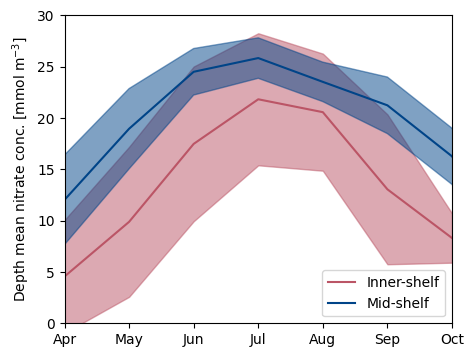

In [84]:
fig, axs = plt.subplots(1, 1, figsize=(5, 4), sharex=True)

axs.plot(
    inner_depth_mean_monthly["month"],
    inner_depth_mean_monthly["nitrate"],
    color="#BB5566",
    label="Inner-shelf",
)

axs.fill_between(
    inner_depth_mean_monthly["month"],
    inner_depth_mean_monthly["nitrate"] - inner_depth_mean_monthly["nitrate_ci"],
    inner_depth_mean_monthly["nitrate"] + inner_depth_mean_monthly["nitrate_ci"],
    alpha=0.5,
    color="#BB5566",
)

axs.plot(
    midshelf_depth_mean_monthly["month"],
    midshelf_depth_mean_monthly["nitrate"],
    color="#004488",
    label="Mid-shelf",
)

axs.fill_between(
    midshelf_depth_mean_monthly["month"],
    midshelf_depth_mean_monthly["nitrate"] - midshelf_depth_mean_monthly["nitrate_ci"],
    midshelf_depth_mean_monthly["nitrate"] + midshelf_depth_mean_monthly["nitrate_ci"],
    alpha=0.5,
    color="#004488",
)

axs.set_xlim(4, 10)
axs.set_ylim(0, 30)
axs.minorticks_off()
axs.legend(loc="lower right")
axs.xaxis.set_major_formatter(lambda x, pos: calendar.month_abbr[int(x)])  # noqa: ARG005; `pos` is necessary but unused
axs.set_ylabel("Depth mean nitrate conc. [$\\mathsf{mmol \\; m^{-3}}$]")

plt.savefig(
    FIGURES_DIR / f"manuscript/{FIG_SAVE_FMT}/monthly-depth-mean-nitrate.{FIG_SAVE_FMT}",
    format=FIG_SAVE_FMT,
    bbox_inches="tight",
    dpi=600,
)